# Signals Processing Exercises

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams.update({'font.size': 20})

### Exercise

Generate a 10-second random signal with 0.01 second sampling interval and plot it. (Tip: you should use [np.random.random()](https://docs.scipy.org/doc/numpy-1.14.0/reference/routines.random.html) function)

Is the signal continuous or discrete?  Analog or digital?

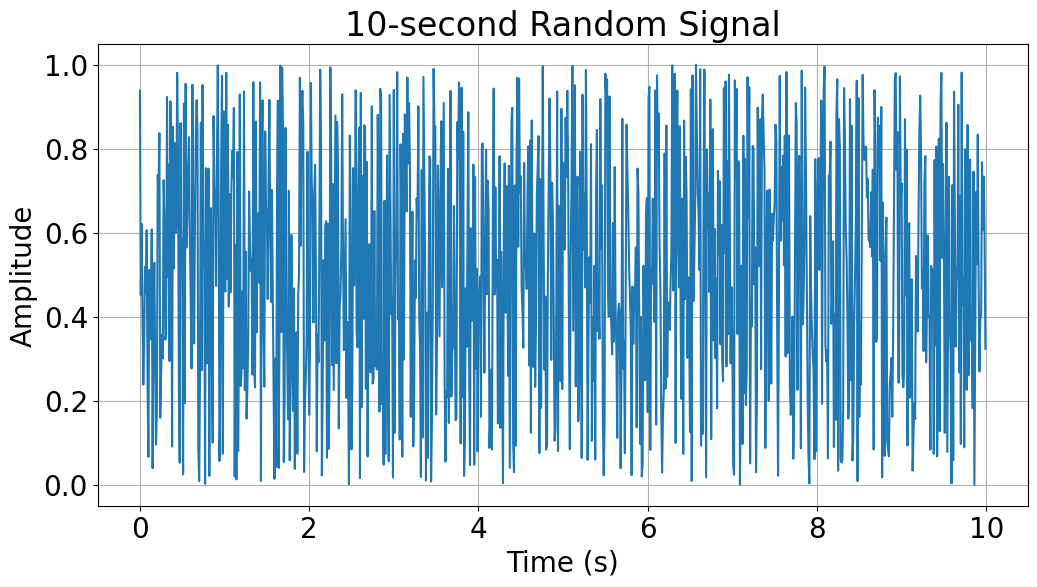

In [3]:
# parameters
sampling_interval = 0.01  # seconds
duration = 10  # seconds

# # of samples
num_samples = int(duration / sampling_interval)

# time vector
time = np.linspace(0, duration, num_samples, endpoint=False)

# generate
signal = np.random.random(num_samples)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time, signal)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('10-second Random Signal')
plt.grid(True)
plt.show()

Answer: The signal is discrete and digital. Any signal comprised of finite number of samples is discrete. And because signal values are stored in a finite number of bits, their magnitudes can only assume a finite set of possible values.

### ECG Example
The file ecg.txt contains 15000 data points of ECG data, sampled at 1000 Hz.  Plot the signal with appropriate time axis.

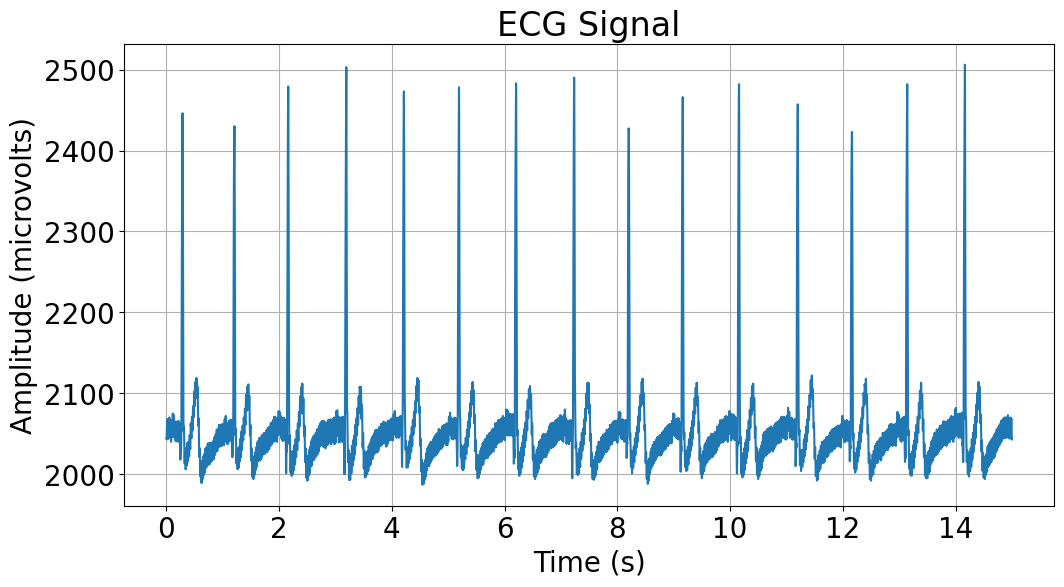

In [6]:
# Load the ECG example data
ecG_url = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/ecg.txt'
ecG_microvolts = np.loadtxt(ecG_url,skiprows=4)

# sampling rat
sampling_rate = 1000 # Hz

# time vector
num_samples_ecg = len(ecG_microvolts)
duration_ecg = num_samples_ecg / sampling_rate
time_ecg = np.linspace(0, duration_ecg, num_samples_ecg, endpoint=False)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time_ecg, ecG_microvolts)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (microvolts)')
plt.title('ECG Signal')
plt.grid(True)
plt.show()

__Question__

Estimate frequency and amplitude of the above ECG signal (NOT using code!)

__Answer__

Frequency = 1 Amplitude =2450

__Exercise__

Generate and plot a sinusoidal signal with frequency 0.2 HZ and amplitude of 1.5.

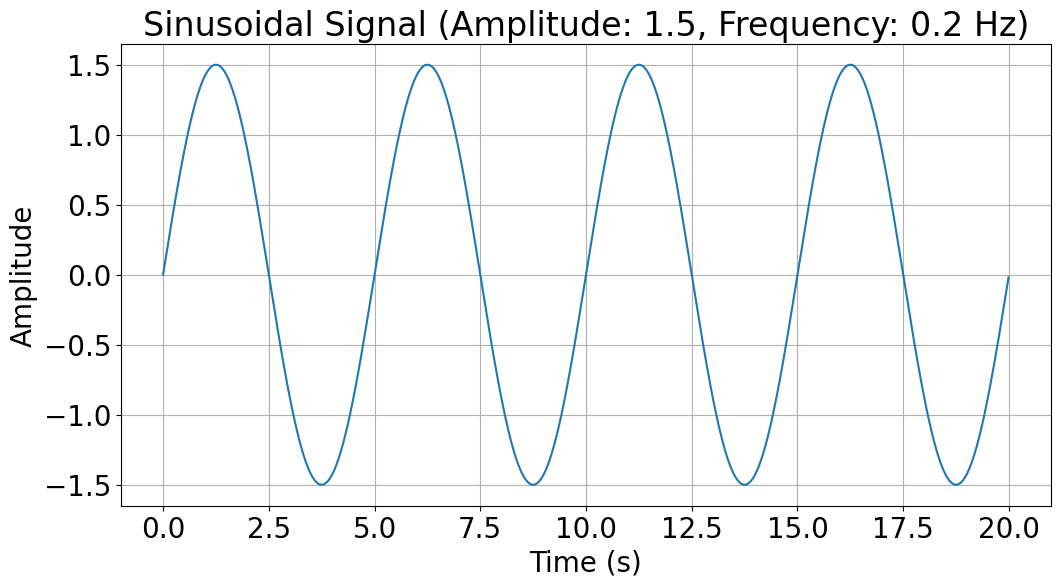

In [7]:
# parameters
amplitude = 1.5
frequency = 0.2 # Hz

# sampling and duration
duration_sine = 20
sampling_rate_sine = 100

#time vector
num_samples_sine = int(duration_sine * sampling_rate_sine)
time_sine = np.linspace(0, duration_sine, num_samples_sine, endpoint=False)

# generate
sin_signal = amplitude * np.sin(2 * np.pi * frequency * time_sine)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time_sine, sin_signal)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Sinusoidal Signal (Amplitude: {amplitude}, Frequency: {frequency} Hz)')
plt.grid(True)
plt.show()

__Exercise__

Consider the signal shown below (the sum of two sinusoids) for this question. How many points do you need in your subsample to completely determine the signal? What frequencies do you have in your signal?

(-2.0, 2.0)

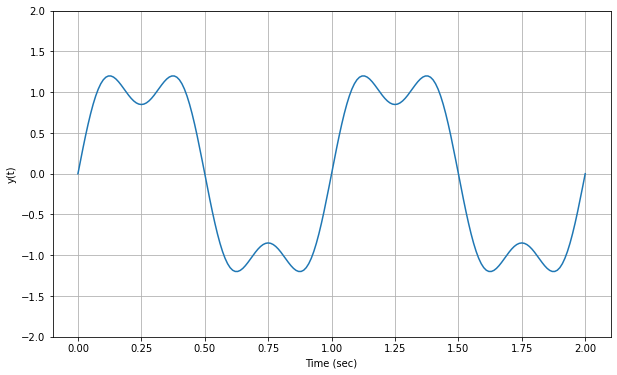

In [ ]:
t = np.linspace(0,2,201)
y = (4/np.pi)*np.sin(2*np.pi*t) + (4/(3*np.pi))*np.sin(6*np.pi*t)

plt.figure(figsize=(10,6))
plt.plot(t,y)
plt.xlabel('Time (sec)')
plt.ylabel('y(t)')
plt.grid()
plt.ylim([-2,2])

__Answer__

1. 1hz and 3hz

2. per nyquist - 2x the highest freq (3hz). so 6 pts/s * 2s = 12

__Exercise__

Plot the peaks from the ECG signal. You can take a look at scipy.signal's documentation for [find_peaks](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html#scipy.signal.find_peaks)

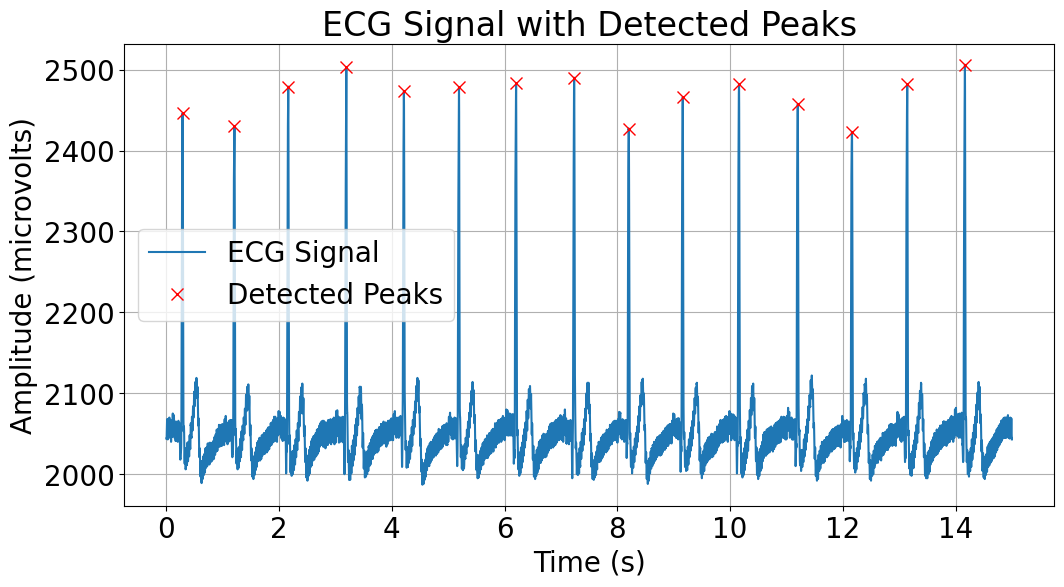

In [9]:
# Load the ECG example data
ecG_url = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/ecg.txt'
ecG_microvolts = np.loadtxt(ecG_url,skiprows=4)

# import
from scipy.signal import find_peaks

# sample rate (assume 1000?)
sampling_rate = 1000

# time vector
num_samples_ecg = len(ecG_microvolts)
duration_ecg = num_samples_ecg / sampling_rate
time_ecg = np.linspace(0, duration_ecg, num_samples_ecg, endpoint=False)

peaks, _ = find_peaks(ecG_microvolts, height=2250, distance=500)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time_ecg, ecG_microvolts, label='ECG Signal')
plt.plot(time_ecg[peaks], ecG_microvolts[peaks], 'x', color='red', markersize=8, label='Detected Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (microvolts)')
plt.title('ECG Signal with Detected Peaks')
plt.grid(True)
plt.legend()
plt.show()

__Exercise__

1. Generate 5 sine waves with frequencies and amplitudes set based on two user-defined lists and sum them into one signal.
2. Plot the 5 original sine waves and the combined signal.
3. Plot x markers at the peaks of the waves using find_peaks

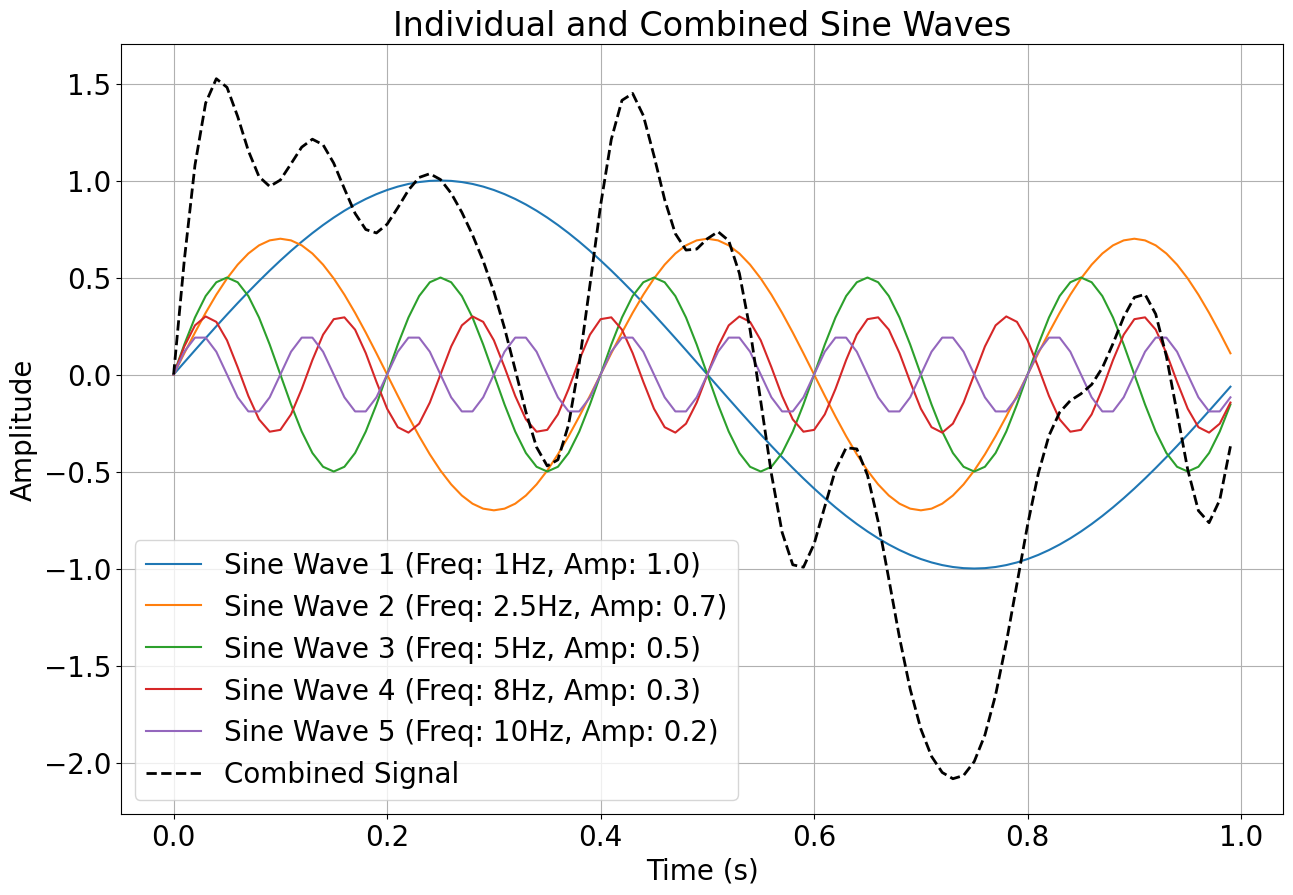

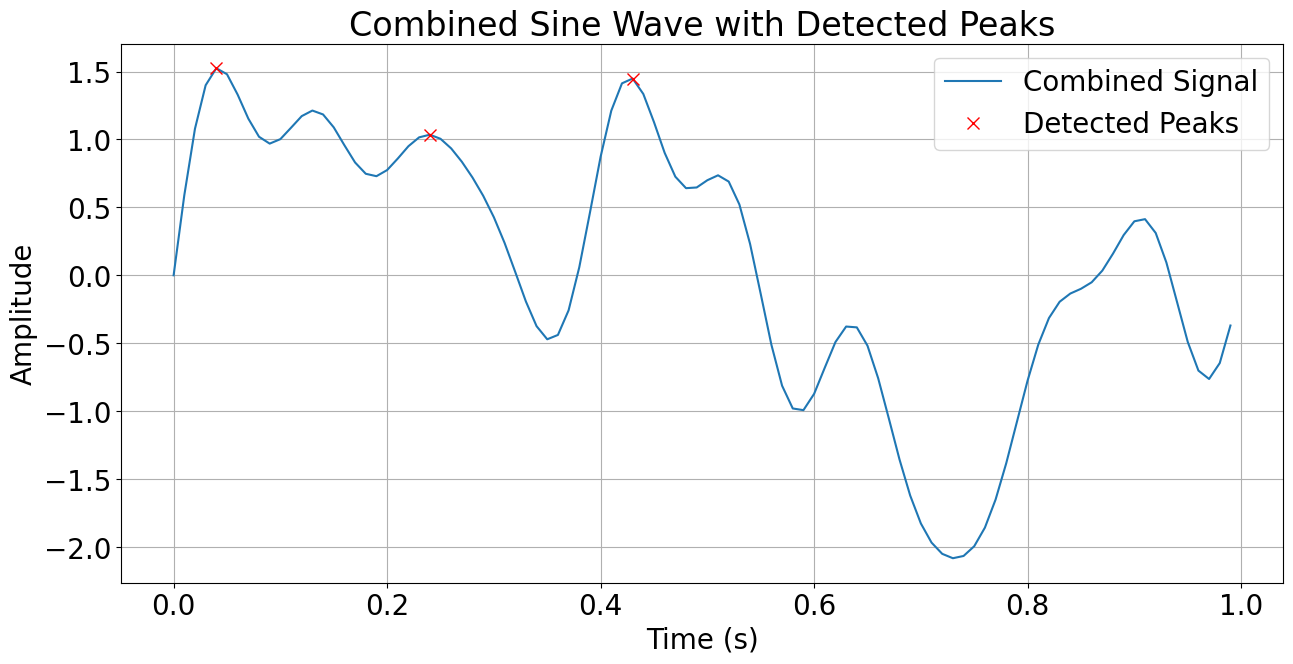

In [11]:
# user defined list
frequencies = [1, 2.5, 5, 8, 10]
amplitudes = [1.0, 0.7, 0.5, 0.3, 0.2]

# parameters
duration = 1
sampling_rate = 100

# time vector
time = np.linspace(0, duration, int(duration * sampling_rate), endpoint=False)

# cmbine waves
sine_waves = []
combined_signal = np.zeros_like(time)

for i in range(len(frequencies)):
    freq = frequencies[i]
    amp = amplitudes[i]
    sine_wave = amp * np.sin(2 * np.pi * freq * time)
    sine_waves.append(sine_wave)
    combined_signal += sine_wave

# plot "separate"
plt.figure(figsize=(15, 10))

for i, sine_wave in enumerate(sine_waves):
    plt.plot(time, sine_wave, label=f'Sine Wave {i+1} (Freq: {frequencies[i]}Hz, Amp: {amplitudes[i]})')

plt.plot(time, combined_signal, 'k--', linewidth=2, label='Combined Signal')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Individual and Combined Sine Waves')
plt.grid(True)
plt.legend()
plt.show()

# find peaks
peak_height_threshold = 0.5 * np.max(combined_signal)
peaks, _ = find_peaks(combined_signal, height=peak_height_threshold, distance=10)

# plot combine
plt.figure(figsize=(15, 7))
plt.plot(time, combined_signal, label='Combined Signal')
plt.plot(time[peaks], combined_signal[peaks], 'x', color='red', markersize=8, label='Detected Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Combined Sine Wave with Detected Peaks')
plt.grid(True)
plt.legend()
plt.show()